0.cek data

In [ ]:
pip install joblib

In [13]:
import pandas as pd 
import numpy as np

data = pd.read_csv("dataset.csv")

data.replace("-", np.nan, inplace=True)
data.columns = data.columns.str.strip()

print("\nJumlah Data Kosong:")
print(data.isnull().sum())

print("\nTotal Data Kosong:")
print(data.isnull().sum().sum())

print(data.isnull().sum())
print("total data kosong =",data.isnull().sum().sum())
print(data.head())
print(data.shape)


Jumlah Data Kosong:
No                       0
Kategori / Indikator     1
Sub Indikator            2
Satuan                   2
2020                    28
2021                    33
2022                    74
2023                    50
2024                     6
dtype: int64

Total Data Kosong:
196
No                       0
Kategori / Indikator     1
Sub Indikator            2
Satuan                   2
2020                    28
2021                    33
2022                    74
2023                    50
2024                     6
dtype: int64
total data kosong = 196
  No       Kategori / Indikator          Sub Indikator     Satuan        2020  \
0  1       Jumlah Produksi Padi  Kabupaten Tulungagung        Ton  313.833.19   
1  2  Jumlah Panen Tanaman Buah                Alpukat  Pohon/Rmp   41.142.00   
2  3  Jumlah Panen Tanaman Buah               Rambutan  Pohon/Rmp   52.493.00   
3  4  Jumlah Panen Tanaman Buah                   Duku  Pohon/Rmp    7.863.00   
4  5  Jumlah P

1.Data Cleaning


In [ ]:
import pandas as pd
import numpy as np

# ==================================================
# 1. MEMBACA DATASET
# ==================================================

print("=" * 50)
print("MEMBACA DATASET")
print("=" * 50)

data = pd.read_csv("dataset.csv")

# ==================================================
# 2. INFORMASI AWAL DATASET
# ==================================================

print("\nUkuran Dataset:")
print(data.shape)

print("\n5 Data Pertama:")
print(data.head())

print("\nTipe Data Awal:")
print(data.dtypes)

print("\nMissing Value Awal:")
print(data.isnull().sum())

print("\nTotal Missing Value:")
print(data.isnull().sum().sum())

# ==================================================
# 3. MENGUBAH '-' MENJADI NaN
# ==================================================

data.replace("-", np.nan, inplace=True)

# ==================================================
# 4. MEMBERSIHKAN NAMA KOLOM
# ==================================================

data.columns = data.columns.str.strip()

# ==================================================
# 5. MENGHAPUS BARIS YANG KOSONG SEMUA
# ==================================================

data.dropna(how="all", inplace=True)

# ==================================================
# 6. MENGHAPUS KOLOM NO
# ==================================================

if "No" in data.columns:
    data.drop(columns=["No"], inplace=True)

# ==================================================
# 7. MEMBERSIHKAN SPASI PADA KOLOM TEKS
# ==================================================

kolom_teks = [
    "Kategori / Indikator",
    "Sub Indikator",
    "Satuan"
]

for col in kolom_teks:

    if col in data.columns:

        data[col] = (
            data[col]
            .astype(str)
            .str.strip()
        )

# ==================================================
# 8. FUNGSI KONVERSI ANGKA
# ==================================================

def convert_number(x):

    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x == "":
        return np.nan

    if x == "-":
        return np.nan

    parts = x.split(".")

    if len(parts) > 2:
        x = "".join(parts[:-1]) + "." + parts[-1]

    try:
        return float(x)

    except:
        return np.nan

# ==================================================
# 9. KONVERSI KOLOM TAHUN MENJADI FLOAT
# ==================================================

kolom_tahun = [
    "2020",
    "2021",
    "2022",
    "2023",
    "2024"
]

for col in kolom_tahun:

    if col in data.columns:

        data[col] = data[col].apply(convert_number)

# ==================================================
# 10. CEK TIPE DATA SETELAH KONVERSI
# ==================================================

print("\nTipe Data Setelah Konversi:")
print(data.dtypes)

# ==================================================
# 11. MENGISI MISSING VALUE
# ==================================================

for col in kolom_tahun:

    if col in data.columns:

        median = data[col].median()

        data[col] = data[col].fillna(median)

# ==================================================
# 12. CEK DUPLIKAT
# ==================================================

jumlah_duplikat = data.duplicated().sum()

print("\nJumlah Data Duplikat:")
print(jumlah_duplikat)

if jumlah_duplikat > 0:

    data = data.drop_duplicates()

    print("Duplikat berhasil dihapus")

# ==================================================
# 13. CEK MISSING VALUE AKHIR
# ==================================================

print("\nMissing Value Setelah Cleaning:")
print(data.isnull().sum())

print("\nTotal Missing Value Setelah Cleaning:")
print(data.isnull().sum().sum())

# ==================================================
# 14. STATISTIK DATA
# ==================================================

print("\nStatistik Dataset:")
print(data.describe())

# ==================================================
# 15. INFO DATASET AKHIR
# ==================================================

print("\nInfo Dataset Setelah Cleaning:")
print(data.info())

print("\nUkuran Dataset Akhir:")
print(data.shape)

# ==================================================
# 16. SIMPAN DATASET BERSIH
# ==================================================

data.to_csv(
    "dataset_bersih.csv",
    index=False
)

print("\nDataset berhasil disimpan!")
print("Nama file: dataset_bersih.csv")

MEMBACA DATASET

Ukuran Dataset:
(181, 9)

5 Data Pertama:
  No       Kategori / Indikator          Sub Indikator     Satuan        2020  \
0  1       Jumlah Produksi Padi  Kabupaten Tulungagung        Ton  313.833.19   
1  2  Jumlah Panen Tanaman Buah                Alpukat  Pohon/Rmp   41.142.00   
2  3  Jumlah Panen Tanaman Buah               Rambutan  Pohon/Rmp   52.493.00   
3  4  Jumlah Panen Tanaman Buah                   Duku  Pohon/Rmp    7.863.00   
4  5  Jumlah Panen Tanaman Buah             Jeruk Siam  Pohon/Rmp  318.440.00   

         2021        2022        2023        2024  
0  340.671.99  310.892.39  285.439.44  257.034.93  
1   71.080.00  134.330.00  118.054.00  124.038.00  
2   44.165.00   39.900.00   28.028.00   24.814.00  
3    7.698.00    1.627.00         840         907  
4  108.894.00  115.721.00         NaN  110.430.00  

Tipe Data Awal:
No                      str
Kategori / Indikator    str
Sub Indikator           str
Satuan                  str
2020         

2.EDA

EDA - EXPLORATORY DATA ANALYSIS

Ukuran Dataset:
(181, 8)

Nama Kolom:
['Kategori / Indikator', 'Sub Indikator', 'Satuan', '2020', '2021', '2022', '2023', '2024']

5 Data Pertama:
        Kategori / Indikator          Sub Indikator     Satuan       2020  \
0       Jumlah Produksi Padi  Kabupaten Tulungagung        Ton  313833.19   
1  Jumlah Panen Tanaman Buah                Alpukat  Pohon/Rmp   41142.00   
2  Jumlah Panen Tanaman Buah               Rambutan  Pohon/Rmp   52493.00   
3  Jumlah Panen Tanaman Buah                   Duku  Pohon/Rmp    7863.00   
4  Jumlah Panen Tanaman Buah             Jeruk Siam  Pohon/Rmp  318440.00   

        2021       2022       2023       2024  
0  340671.99  310892.39  285439.44  257034.93  
1   71080.00  134330.00  118054.00  124038.00  
2   44165.00   39900.00   28028.00   24814.00  
3    7698.00    1627.00     840.00     907.00  
4  108894.00  115721.00    3765.00  110430.00  

5 Data Terakhir:
         Kategori / Indikator          Sub Indikato

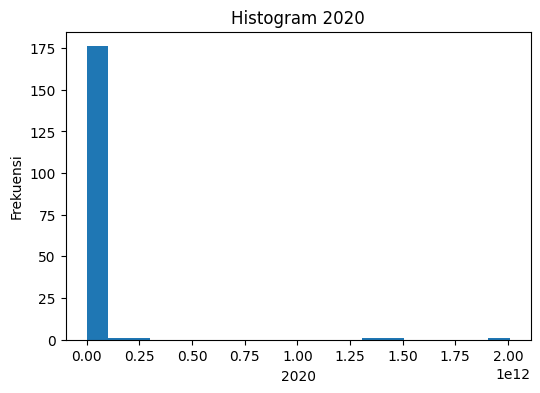

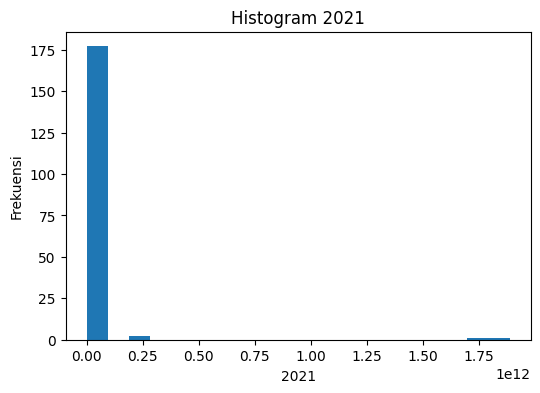

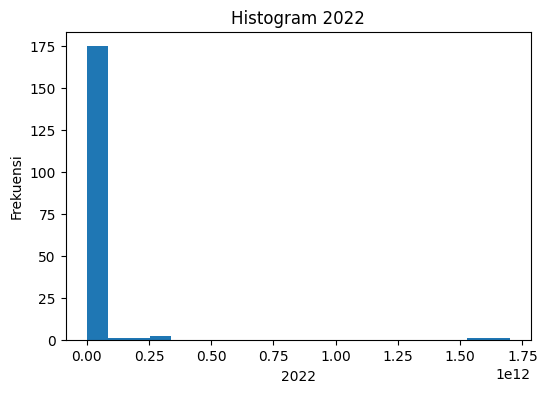

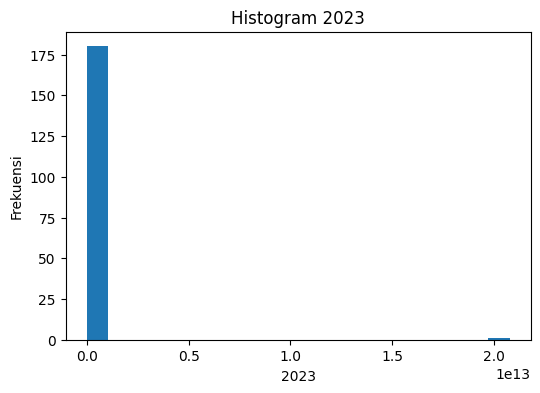

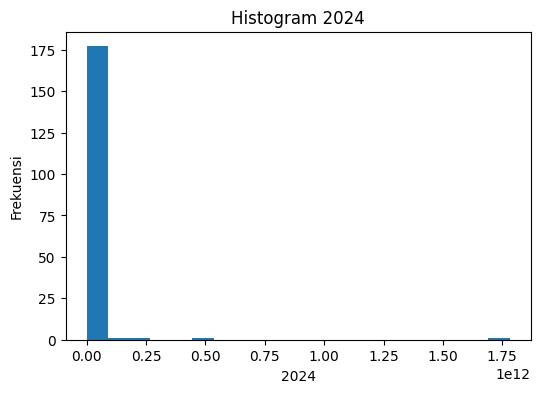

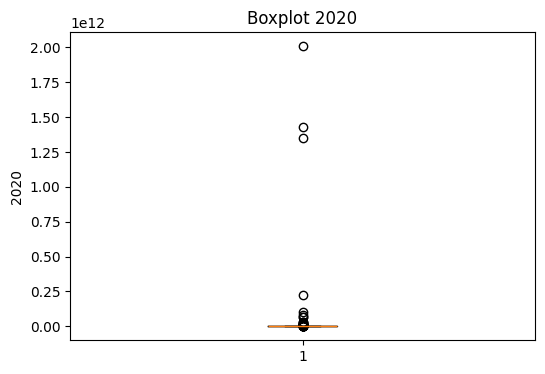

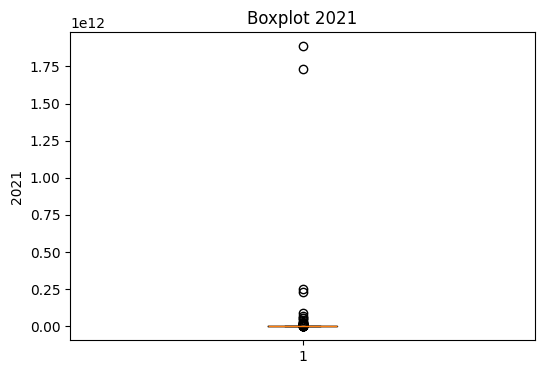

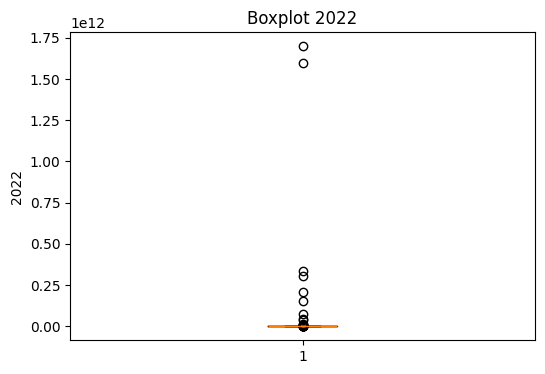

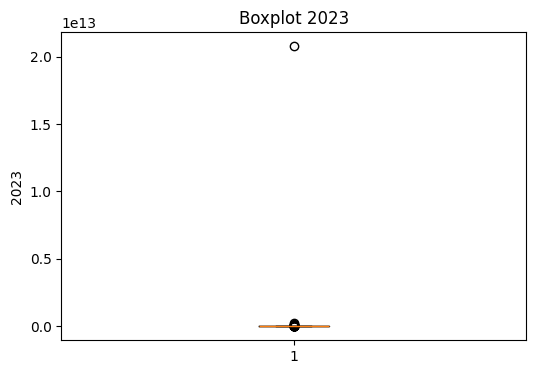

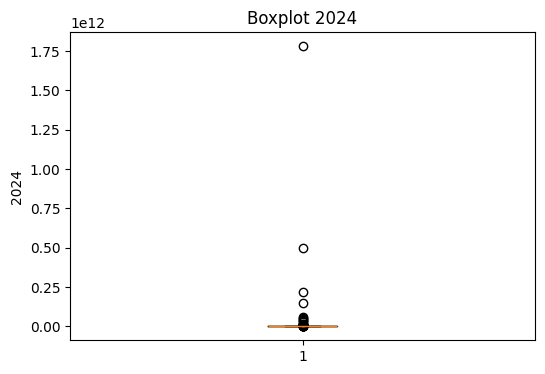


OUTLIER ANALYSIS
2020 -> 45 outlier
2021 -> 41 outlier
2022 -> 38 outlier
2023 -> 42 outlier
2024 -> 40 outlier


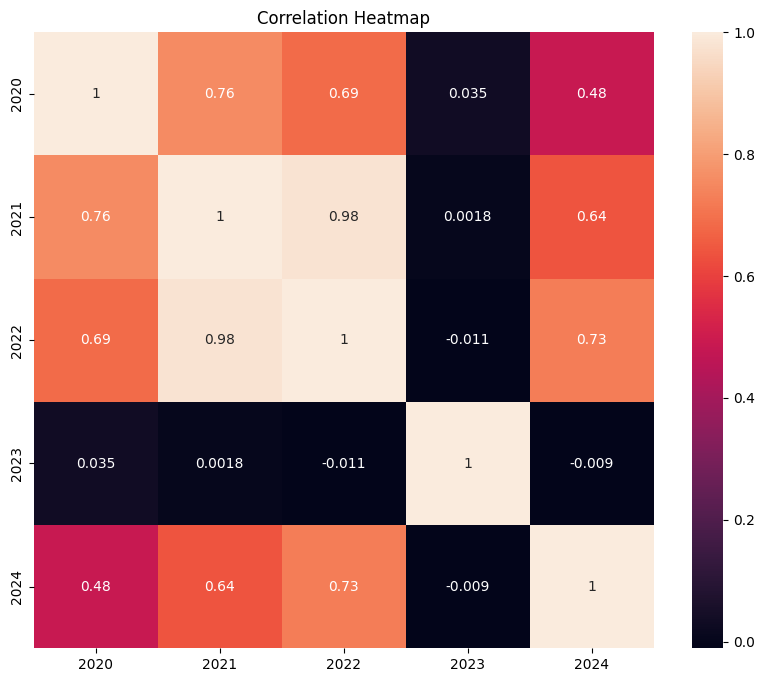


ANALISIS KATEGORIKAL

Kolom : Kategori / Indikator
Kategori / Indikator
Jumlah Produksi Sayuran                     20
Nilai Produksi Sayuran                      20
Luas Lahan Tanaman Sayuran                  20
Jumlah Panen Tanaman Buah                   18
Jumlah Produksi Tanaman Buah                18
Nilai Produksi Buah-Buahan                  18
Luas Bencana Alam pada Tanaman Pertanian    16
Jumlah Ketersediaan Obat Anti Hama           6
Luas Areal Tanaman Tahunan                   5
Jumlah Produksi Tanaman Tahunan              5
Name: count, dtype: int64

Kolom : Sub Indikator
Sub Indikator
Kabupaten Tulungagung    22
Tembakau                  4
Bawang Merah              4
Kacang Panjang            4
Tomat                     4
Terong                    4
Buncis                    4
Alpukat                   3
Rambutan                  3
Duku                      3
Name: count, dtype: int64

Kolom : Satuan
Satuan
Rp           50
Ha           48
Kw           39
Pohon/Rmp    18
T

C:\Users\PC\AppData\Local\Temp\ipykernel_13992\502167567.py:216: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  kolom_kategori = data.select_dtypes(


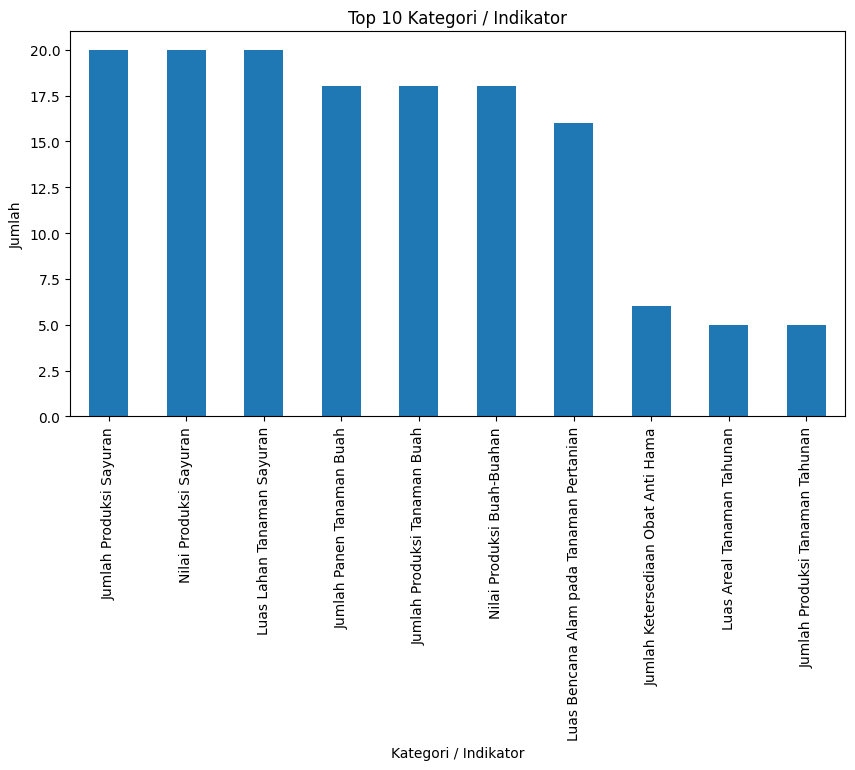

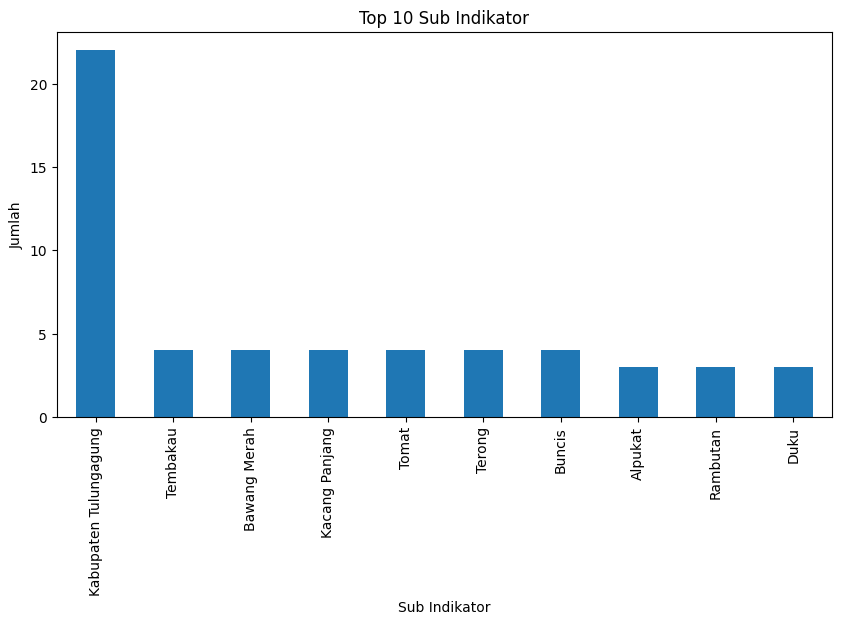

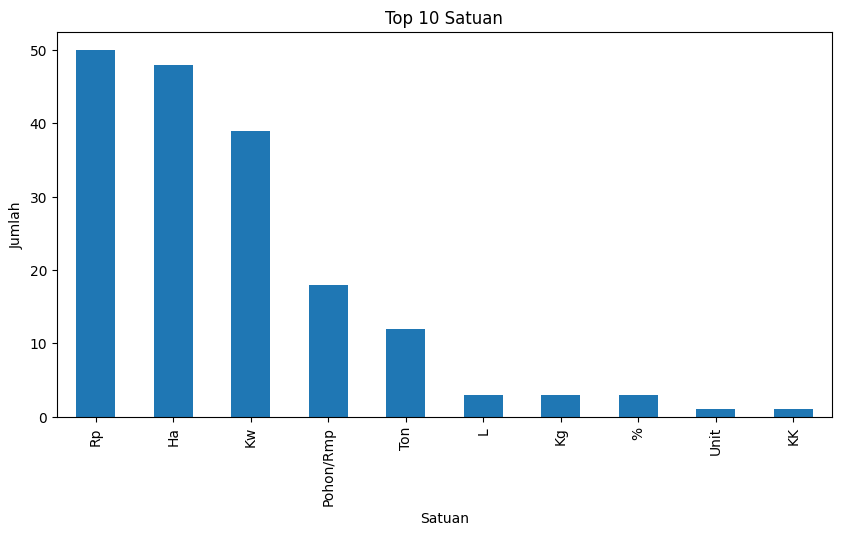

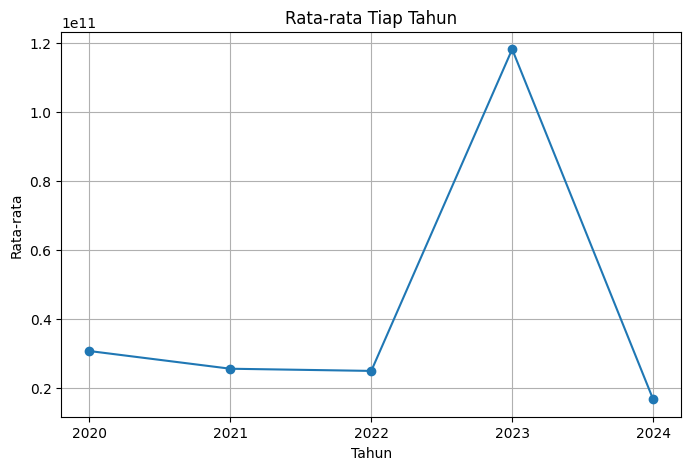

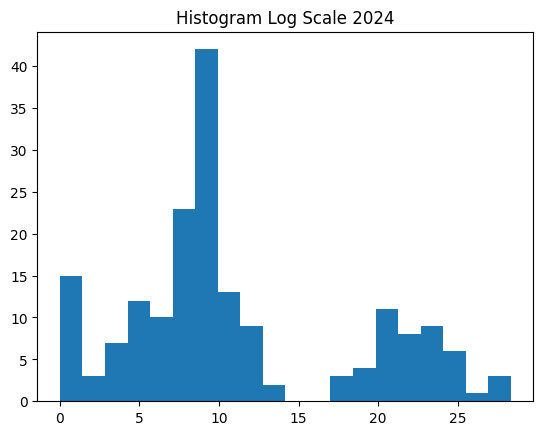


EDA SELESAI
Jumlah Baris : 181
Jumlah Kolom : 8
Jumlah Kolom Numerik : 5
Jumlah Kolom Kategorikal : 3

Analisis berhasil dilakukan.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    seaborn_tersedia = True
except:
    seaborn_tersedia = False

# ==================================================
# 1. MEMBACA DATASET BERSIH
# ==================================================

print("=" * 60)
print("EDA - EXPLORATORY DATA ANALYSIS")
print("=" * 60)

data = pd.read_csv("dataset_bersih.csv")

# ==================================================
# 2. INFORMASI DASAR DATASET
# ==================================================

print("\nUkuran Dataset:")
print(data.shape)

print("\nNama Kolom:")
print(list(data.columns))

print("\n5 Data Pertama:")
print(data.head())

print("\n5 Data Terakhir:")
print(data.tail())

# ==================================================
# 3. INFO DATASET
# ==================================================

print("\nINFO DATASET")
print("=" * 60)

data.info()

# ==================================================
# 4. CEK TIPE DATA
# ==================================================

print("\nTIPE DATA")
print("=" * 60)

print(data.dtypes)

# ==================================================
# 5. CEK MISSING VALUE
# ==================================================

print("\nMISSING VALUE")
print("=" * 60)

print(data.isnull().sum())

print("\nTOTAL MISSING VALUE:")
print(data.isnull().sum().sum())

# ==================================================
# 6. CEK DUPLIKAT
# ==================================================

print("\nDATA DUPLIKAT")
print("=" * 60)

print(data.duplicated().sum())

# ==================================================
# 7. STATISTIK DESKRIPTIF
# ==================================================

print("\nSTATISTIK DESKRIPTIF")
print("=" * 60)

print(data.describe())

# ==================================================
# 8. PILIH KOLOM NUMERIK
# ==================================================

data_numerik = data.select_dtypes(
    include=["int64", "float64"]
)

print("\nKOLOM NUMERIK:")
print(list(data_numerik.columns))

# ==================================================
# 9. ANALISIS KOLOM NUMERIK
# ==================================================

print("\nANALISIS NUMERIK")
print("=" * 60)

for col in data_numerik.columns:

    print(f"\nKolom : {col}")

    print("Mean   :", data[col].mean())
    print("Median :", data[col].median())
    print("Min    :", data[col].min())
    print("Max    :", data[col].max())
    print("Std    :", data[col].std())

# ==================================================
# 10. KORELASI
# ==================================================

print("\nKORELASI")
print("=" * 60)

corr = data_numerik.corr()

print(corr)

# ==================================================
# 11. HISTOGRAM
# ==================================================

for col in data_numerik.columns:

    plt.figure(figsize=(6,4))

    plt.hist(
        data[col],
        bins=20
    )

    plt.title(f"Histogram {col}")

    plt.xlabel(col)

    plt.ylabel("Frekuensi")

    plt.show()

# ==================================================
# 12. BOXPLOT
# ==================================================

for col in data_numerik.columns:

    plt.figure(figsize=(6,4))

    plt.boxplot(data[col])

    plt.title(f"Boxplot {col}")

    plt.ylabel(col)

    plt.show()

# ==================================================
# 13. DETEKSI OUTLIER DENGAN IQR
# ==================================================

print("\nOUTLIER ANALYSIS")
print("=" * 60)

for col in data_numerik.columns:

    Q1 = data[col].quantile(0.25)

    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)

    upper = Q3 + (1.5 * IQR)

    outlier = data[
        (data[col] < lower)
        |
        (data[col] > upper)
    ]

    print(
        f"{col} -> {len(outlier)} outlier"
    )

# ==================================================
# 14. HEATMAP KORELASI
# ==================================================

if seaborn_tersedia:

    plt.figure(figsize=(10,8))

    sns.heatmap(
        corr,
        annot=True
    )

    plt.title(
        "Correlation Heatmap"
    )

    plt.show()

# ==================================================
# 15. ANALISIS KOLOM KATEGORIKAL
# ==================================================

print("\nANALISIS KATEGORIKAL")
print("=" * 60)

kolom_kategori = data.select_dtypes(
    include=["object"]
).columns

for col in kolom_kategori:

    print(f"\nKolom : {col}")

    print(
        data[col]
        .value_counts()
        .head(10)
    )

# ==================================================
# 16. BARPLOT KATEGORI
# ==================================================

for col in kolom_kategori:

    plt.figure(figsize=(10,5))

    data[col].value_counts().head(10).plot(
        kind="bar"
    )

    plt.title(
        f"Top 10 {col}"
    )

    plt.xlabel(col)

    plt.ylabel("Jumlah")

    plt.show()

# ==================================================
# 17. ANALISIS TAHUN
# ==================================================

kolom_tahun = [
    "2020",
    "2021",
    "2022",
    "2023",
    "2024"
]

kolom_tahun = [
    c for c in kolom_tahun
    if c in data.columns
]

if len(kolom_tahun) > 0:

    rata_tahun = []

    for col in kolom_tahun:

        rata_tahun.append(
            data[col].mean()
        )

    plt.figure(figsize=(8,5))

    plt.plot(
        kolom_tahun,
        rata_tahun,
        marker="o"
    )

    plt.title(
        "Rata-rata Tiap Tahun"
    )

    plt.xlabel("Tahun")

    plt.ylabel("Rata-rata")

    plt.grid()

    plt.show()


    
# ==================================================
# 18. KESIMPULAN SINGKAT
# ==================================================


plt.hist(
    np.log1p(data['2020']),
    bins = 20
)

plt.title("Histogram Log Scale 2024")
plt.show()

print("\nEDA SELESAI")
print("=" * 60)

print("Jumlah Baris :", data.shape[0])
print("Jumlah Kolom :", data.shape[1])

print(
    "Jumlah Kolom Numerik :",
    len(data_numerik.columns)
)

print(
    "Jumlah Kolom Kategorikal :",
    len(kolom_kategori)
)

print("\nAnalisis berhasil dilakukan.")

In [1]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
# ==================================================
# IMPORT LIBRARY
# ==================================================

import pandas as pd
import joblib

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==================================================
# 1. MEMBACA DATASET
# ==================================================

data = pd.read_csv(
    "dataset_bersih.csv"
)

print("\nUkuran Dataset:")
print(data.shape)

print("\n5 Data Pertama:")
print(data.head())

# ==================================================
# 2. TARGET
# ==================================================

y = data["2024"]

# ==================================================
# 3. FITUR
# ==================================================

X = data.drop(
    columns=["2024"]
)

# ==================================================
# 4. KOLOM KATEGORIK
# ==================================================

categorical_features = []

for col in [
    "Kategori",
    "Sub Indikator",
    "Satuan"
]:

    if col in X.columns:

        categorical_features.append(col)

print("\nKolom Kategorik:")
print(categorical_features)

# ==================================================
# 5. PREPROCESSOR
# ==================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",

            OneHotEncoder(
                handle_unknown="ignore"
            ),

            categorical_features
        )
    ],

    remainder="passthrough"
)

# ==================================================
# 6. PIPELINE
# ==================================================

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "regressor",
        LinearRegression()
    )
])

# ==================================================
# 7. TRAIN TEST SPLIT
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nData Training:")
print(X_train.shape)

print("\nData Testing:")
print(X_test.shape)

# ==================================================
# 8. TRAINING
# ==================================================

print("\nTraining Model...")

model.fit(
    X_train,
    y_train
)

print("Training Selesai!")

# ==================================================
# 9. PREDIKSI
# ==================================================

y_pred = model.predict(
    X_test
)

# ==================================================
# 10. EVALUASI
# ==================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = mse ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("\n===== HASIL EVALUASI =====")

print("MAE  :", round(mae, 2))

print("RMSE :", round(rmse, 2))

print("R²   :", round(r2, 4))

# ==================================================
# 11. HASIL PREDIKSI
# ==================================================

hasil = pd.DataFrame({
    "Aktual": y_test,
    "Prediksi": y_pred
})

print("\nAktual VS Prediksi:")
print(
    hasil.head(10)
)

# ==================================================
# 12. SIMPAN MODEL
# ==================================================

joblib.dump(
    model,
    "model_pertanian.pkl"
)

print("\nModel berhasil disimpan!")

# ==================================================
# 13. LOAD MODEL
# ==================================================

model_load = joblib.load(
    "model_pertanian.pkl"
)

print("\nModel berhasil dimuat!")

# ==================================================
# 14. CONTOH PREDIKSI BARU
# ==================================================

data_baru = pd.DataFrame({
    "Kategori": ["Tanaman Pangan"],
    "Sub Indikator": ["Padi"],
    "Satuan": ["Ton"],
    "2020": [313833],
    "2021": [340671],
    "2022": [310892],
    "2023": [285439]
})

hasil_prediksi = model_load.predict(
    data_baru
)

print(
    "\nPrediksi Tahun 2024:"
)

print(
    hasil_prediksi[0]
)


Ukuran Dataset:
(181, 8)

5 Data Pertama:
        Kategori / Indikator          Sub Indikator     Satuan       2020  \
0       Jumlah Produksi Padi  Kabupaten Tulungagung        Ton  313833.19   
1  Jumlah Panen Tanaman Buah                Alpukat  Pohon/Rmp   41142.00   
2  Jumlah Panen Tanaman Buah               Rambutan  Pohon/Rmp   52493.00   
3  Jumlah Panen Tanaman Buah                   Duku  Pohon/Rmp    7863.00   
4  Jumlah Panen Tanaman Buah             Jeruk Siam  Pohon/Rmp  318440.00   

        2021       2022       2023       2024  
0  340671.99  310892.39  285439.44  257034.93  
1   71080.00  134330.00  118054.00  124038.00  
2   44165.00   39900.00   28028.00   24814.00  
3    7698.00    1627.00     840.00     907.00  
4  108894.00  115721.00    3765.00  110430.00  

Kolom Kategorik:
['Sub Indikator', 'Satuan']

Data Training:
(144, 7)

Data Testing:
(37, 7)

Training Model...


ValueError: scipy.sparse does not support dtype object. The only supported types are: bool, int8, uint8, int16, uint16, intc, uintc, int32, uint32, int64, uint64, float32, float64, longdouble, complex64, complex128, clongdouble.

In [3]:
# ==================================================
# IMPORT LIBRARY
# ==================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==================================================
# LOAD DATASET
# ==================================================

print("=" * 50)
print("MEMBACA DATASET")
print("=" * 50)

data = pd.read_csv("dataset_bersih.csv")

print(data.head())

print("\nUkuran Dataset:")
print(data.shape)

# ==================================================
# CEK TIPE DATA
# ==================================================

print("\nTipe Data:")
print(data.dtypes)

# ==================================================
# PAKSA KOLOM TAHUN MENJADI NUMERIK
# ==================================================

kolom_tahun = [
    "2020",
    "2021",
    "2022",
    "2023",
    "2024"
]

for col in kolom_tahun:

    if col in data.columns:

        data[col] = pd.to_numeric(
            data[col],
            errors="coerce"
        )

# ==================================================
# ISI MISSING VALUE
# ==================================================

for col in kolom_tahun:

    if col in data.columns:

        data[col] = data[col].fillna(
            data[col].median()
        )

# ==================================================
# TARGET
# ==================================================

y = data["2024"]

# ==================================================
# FITUR
# ==================================================

X = data.drop(
    columns=["2024"]
)

# ==================================================
# DETEKSI KOLOM KATEGORIK OTOMATIS
# ==================================================

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nKolom Kategorik:")
print(categorical_features)

# ==================================================
# PREPROCESSOR
# ==================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

# ==================================================
# PIPELINE
# ==================================================

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "regressor",
        LinearRegression()
    )
])

# ==================================================
# TRAIN TEST SPLIT
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nData Training:")
print(X_train.shape)

print("\nData Testing:")
print(X_test.shape)

# ==================================================
# TRAINING
# ==================================================

print("\nTraining Model...")

model.fit(
    X_train,
    y_train
)

print("Training Selesai!")

# ==================================================
# PREDIKSI
# ==================================================

y_pred = model.predict(
    X_test
)

# ==================================================
# EVALUASI
# ==================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mse
)

r2 = r2_score(
    y_test,
    y_pred
)

print("\n===== HASIL EVALUASI =====")

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 :", r2)

# ==================================================
# HASIL PREDIKSI
# ==================================================

hasil = pd.DataFrame({
    "Aktual": y_test,
    "Prediksi": y_pred
})

print("\nAktual VS Prediksi")

print(
    hasil.head(10)
)

# ==================================================
# SIMPAN MODEL
# ==================================================

joblib.dump(
    model,
    "model_pertanian.pkl"
)

print("\nModel berhasil disimpan")

# ==================================================
# LOAD MODEL
# ==================================================

model_load = joblib.load(
    "model_pertanian.pkl"
)

print(
    "\nModel berhasil dimuat kembali"
)

MEMBACA DATASET
        Kategori / Indikator          Sub Indikator     Satuan       2020  \
0       Jumlah Produksi Padi  Kabupaten Tulungagung        Ton  313833.19   
1  Jumlah Panen Tanaman Buah                Alpukat  Pohon/Rmp   41142.00   
2  Jumlah Panen Tanaman Buah               Rambutan  Pohon/Rmp   52493.00   
3  Jumlah Panen Tanaman Buah                   Duku  Pohon/Rmp    7863.00   
4  Jumlah Panen Tanaman Buah             Jeruk Siam  Pohon/Rmp  318440.00   

        2021       2022       2023       2024  
0  340671.99  310892.39  285439.44  257034.93  
1   71080.00  134330.00  118054.00  124038.00  
2   44165.00   39900.00   28028.00   24814.00  
3    7698.00    1627.00     840.00     907.00  
4  108894.00  115721.00    3765.00  110430.00  

Ukuran Dataset:
(181, 8)

Tipe Data:
Kategori / Indikator        str
Sub Indikator               str
Satuan                      str
2020                    float64
2021                    float64
2022                    float64
202

C:\Users\PC\AppData\Local\Temp\ipykernel_12960\1377722694.py:93: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(



Data Training:
(144, 7)

Data Testing:
(37, 7)

Training Model...
Training Selesai!

===== HASIL EVALUASI =====
MAE : 17294882701.99931
RMSE : 34625497299.04772
R2 : -0.6425323356860417

Aktual VS Prediksi
           Aktual      Prediksi
19   6.346258e+04 -3.445042e+08
42   1.287000e+03  1.706483e+10
153  4.443000e+01 -4.975708e+09
78   2.103000e+03 -3.846921e+09
145  0.000000e+00  6.818523e+09
15   2.609000e+03  1.970494e+09
24   7.559250e+03  2.162364e+09
68   6.772000e+03  1.141130e+09
113  5.476220e+09 -4.285649e+09
118  1.592784e+10  2.643195e+09

Model berhasil disimpan

Model berhasil dimuat kembali
